In [8]:
from pathlib import Path

"""
Replace with your desired directories
"""

from utility import repo_root

FIG_DIR = Path("/Users/zach/2025_RA/matthias/final images/4_expanded_sleep")
FIG_DIR.mkdir(parents=True, exist_ok=True)
BIDS_DIR = Path("/Users/zach/2025_RA/matthias/bids_sleepmreye")
CONFIG_DIR = Path(repo_root() / "sleepmreye" / "designs")

In [50]:
""" Load data """

from mreyemove.analysis.glm.cli import construct_desc
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio_unclean = SleepMRIO(
    bids_root=BIDS_DIR,
    tr=2.1,
    task="sleep",
    load_signal=True,
    ignore_boundary_trs=0,
    load_EOG=False,
)

mrio_clean = SleepMRIO(
    bids_root=BIDS_DIR,
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean",
    ignore_boundary_trs=0,
    load_EOG=False,
)

config_main = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep.yml")
desc_add_main = construct_desc(dataset=mrio_clean, config=config_main)
desc_add_main = f"{desc_add_main}-{config_main.second_level.method}"
print(desc_add_main)

EOG data not full for 16, 1 (0/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (0/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (0/427). Skipping
EOG data not full for 16, 1 (0/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (0/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (0/427). Skipping


clean-original-sleep-flame


# FD vs Gaze Comparison


Per-run correlations (163 runs):
9.78300762841918 [0.22427714 0.33508517]


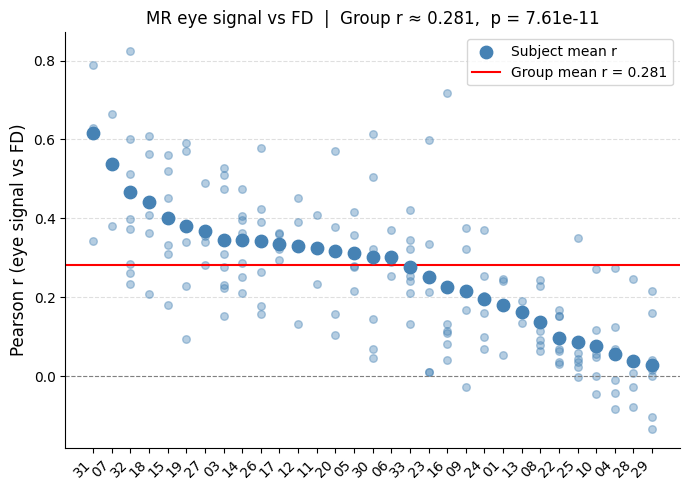

In [51]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ── 1. Collect per-run correlations ──────────────────────────────────────────

records = []

for subject, run, run_df in mrio_unclean.iter_run_events():
    eye_signal = run_df["mreyemove"]

    # It's called conv just because this is the regressor name
    # It's only convolved in glm.first_level so it's the preprocessed signal here
    fd_rows = run_df["conv_framewise_displacement"] 
    if fd_rows.isna().any():
        print(f"  Skipping {subject} run {run} (no FD data)")
        continue

    fd_signal = fd_rows.values.astype(float)

    if len(eye_signal) != len(fd_signal):
        print(f"  Skipping {subject} run {run} (length mismatch: eye={len(eye_signal)}, FD={len(fd_signal)})")
        continue

    r, _ = stats.pearsonr(eye_signal, fd_signal)  
    if np.isnan(r):
        continue

    records.append(dict(
        subject=subject,
        run=run,
        r=r,
        n=len(eye_signal),
        mean_eye=np.mean(np.abs(eye_signal)),
        mean_eog=np.mean(np.abs(fd_signal)),
    ))

run_df = pd.DataFrame(records)
print(f"\nPer-run correlations ({len(run_df)} runs):")

# ── 2. Per-subject average r (Fisher z then back) ────────────────────────────

def fisher_mean_z(r_values):
    """Return Fisher-averaged correlation in z-space."""
    return np.mean(np.arctanh(np.clip(r_values, -0.9999, 0.9999)))

subj_df = (
    run_df.groupby("subject")["r"]
    .agg(z=lambda _r: fisher_mean_z(_r.values), n_runs="count")
    .reset_index()
)
subj_df["r"] = np.tanh(subj_df["z"])  # for display only


# Group-level

z_vals = subj_df["z"].values
mean_z = z_vals.mean()

group_r = np.tanh(mean_z)

t_stat, p_val = stats.ttest_1samp(subj_df["z"].values, 0)
se_z = subj_df["z"].std(ddof=1) / np.sqrt(len(subj_df))
ci_z = mean_z + np.array([-1, 1]) * stats.t.ppf(0.975, len(subj_df)-1) * se_z
ci_r = np.tanh(ci_z)  # e.g. report group r = 0.017, 95% CI [...]

print(t_stat, ci_r)
# ── 4. Plot: per-subject mean r with individual runs ─────────────────────────

subj_plot = subj_df.sort_values("r", ascending=False).reset_index(drop=True)
p_str = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.3f}"

fig, ax = plt.subplots(figsize=(7, 5))

for i, row in subj_plot.iterrows():
    runs = run_df[run_df["subject"] == row["subject"]]["r"].values
    ax.scatter([i] * len(runs), runs, color="steelblue", alpha=0.4, s=30, zorder=2)

ax.scatter(range(len(subj_plot)), subj_plot["r"],
           color="steelblue", s=80, zorder=3, label="Subject mean r")

ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(group_r, color="red", lw=1.5, ls="-", label=f"Group mean r = {group_r:.3f}")

ax.set_xticks(range(len(subj_plot)))
ax.set_xticklabels(subj_plot["subject"].str.replace("sub-", ""), rotation=45, ha="right")
ax.set_ylabel("Pearson r (eye signal vs FD)", fontsize=12)
ax.set_title(f"MR eye signal vs FD  |  Group r ≈ {group_r:.3f},  p = {p_str}", fontsize=12)
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "mreyemove_fd_r_per_subject.svg", dpi=300)
plt.show()

## FD state-differences

In [41]:
from scipy.stats import ttest_1samp

l1 = "W"
l2 = "S"

def create_blocks(arr, trim: int):
    # Get indices where values are not NaN
    valid = ~np.isnan(arr)
    # Find contiguous blocks
    changes = np.diff(valid.astype(int))
    block_starts = np.where(changes == 1)[0] + 1
    block_ends = np.where(changes == -1)[0] + 1
    
    # Handle edge cases where array starts/ends with valid values
    if valid[0]:
        block_starts = np.concatenate([[0], block_starts])
    if valid[-1]:
        block_ends = np.concatenate([block_ends, [len(arr)]])
    
    blocks = [arr[s+trim:e-trim] for s, e in zip(block_starts, block_ends) 
          if (e - trim) - (s + trim) > 0]
    return blocks



def permute_labels(blocks):
    labels = [l for _, l in blocks]
    np.random.shuffle(labels)
    return [(b, l) for (b, _), l in zip(blocks, labels)]




subject_blocks = {}
for subject in mrio_unclean.subjects:
    blocks = []
    
    # For each run, get contiguous sleep and wake blocks,
    # trimming the edge TRs off
    for _, run, run_df in mrio_unclean.iter_run_events(subject=subject):
        eye_signal = run_df["conv_framewise_displacement"]
        wake = np.full_like(eye_signal, np.nan)
        wake[run_df[l1]] = eye_signal[run_df[l1]]
        for block in create_blocks(wake, trim=1):
            blocks.append((block, l1))
        
        sleep = np.full_like(eye_signal, np.nan)
        sleep[run_df[l2]] = eye_signal[run_df[l2]]
        for block in create_blocks(sleep, trim=1):
            blocks.append((block, l2))
    
    subject_blocks[subject] = blocks
        
subject_blocks = {
    s: blocks for s, blocks in subject_blocks.items()
    if any(l == l2 for _, l in blocks)  
}
    

def compute_statistic(blocks, stat, l1, l2):
    """
    Compute statistic per subject
    Find the difference in descriptors for each state using all 
    contiguous state blocks across runs 
    Parameters
    ----------
    blocks
    stat

    Returns
    -------

    """
    wake_vals = np.concatenate([b for b, l in blocks if l == l1])
    sleep_vals = np.concatenate([b for b, l in blocks if l == l2])
    if stat == "mean":
        return np.mean(wake_vals) - np.mean(sleep_vals)
    elif stat == "std":
        return np.std(wake_vals) - np.std(sleep_vals)
    elif stat == "count":
        return len(wake_vals) - len(sleep_vals)
    elif stat == "median":
        return np.median(wake_vals) - np.median(sleep_vals)
    elif stat == "iqr":
        return np.percentile(wake_vals, 75) - np.percentile(sleep_vals, 25)

def permutation_test(subject_blocks, stat, n_permutations=10000):
    subjects = list(subject_blocks.keys())
    
    subj_zs = []
    means = []
    for subject in subjects:
        subj_null_distribution = []
        for _ in range(n_permutations):
            perm_stats = np.array([
                compute_statistic(permute_labels(subject_blocks[subject]), stat, l1, l2) 
            ])
            subj_null_distribution.append(np.mean(perm_stats))
        shuffled_mean = np.mean(subj_null_distribution)
        shuffled_std = np.std(subj_null_distribution)
        observed_mean = compute_statistic(subject_blocks[subject], stat, l1, l2)
        
        subj_z = (observed_mean - shuffled_mean) / shuffled_std
        subj_zs.append(subj_z)
        means.append(observed_mean)
    return np.mean(subj_zs), subj_zs, np.mean(means)


print("Count")
mean_zs, zs, obs  = permutation_test(subject_blocks, stat="count", n_permutations=10000)
print(f"obs mean: {obs}, mean z: {mean_zs}, {ttest_1samp(zs, 0, alternative='two-sided')}")

print("Mean")
mean_zs, zs, obs  = permutation_test(subject_blocks, stat="mean", n_permutations=10000)
print(f"obs mean: {obs}, mean z: {mean_zs}, {ttest_1samp(zs, 0, alternative='two-sided')}")


print("Std")
mean_zs, zs, obs  = permutation_test(subject_blocks, stat="std", n_permutations=10000)
print(f"obs mean: {obs}, mean z: {mean_zs}, {ttest_1samp(zs, 0, alternative='two-sided')}")


Count
obs mean: -69.96774193548387, mean z: -0.4471511837405218, TtestResult(statistic=-1.4121187975960086, pvalue=0.1682045364049997, df=30)
Mean
obs mean: 0.0497435943903461, mean z: 0.9756708735822818, TtestResult(statistic=3.2302892215681966, pvalue=0.0029950154814767046, df=30)
Std
obs mean: 0.12745900713009595, mean z: 0.9245733589117303, TtestResult(statistic=4.051376867371227, pvalue=0.00033150040972775447, df=30)


# Main Analysis vs "Uncleaned" Regressor

## Searchlight

In [53]:

comparisons = [
    "mreyemove",
    "mreyemove_W",
    "mreyemove_S",
]
corr_maps = {}

config_unclean = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep.yml")
desc_add_unclean = construct_desc(dataset=mrio_raw, config=config_unclean)
desc_add_unclean = f"{desc_add_unclean}-{config_unclean.second_level.method}"
print(desc_add_unclean)



original-sleep-flame


In [42]:
"""
Building neighbourhoods takes a while - just do it once
"""

from mreyemove.analysis.searchlight_correlation import build_fsaverage_neighborhoods
radius_mm = 38  # geodesic radius in mm
surf_mesh = "fsaverage7"

cerebrum_neighborhoods = build_fsaverage_neighborhoods(surf_mesh=surf_mesh, radius_mm=radius_mm)

[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Building geodesic neighborhoods (radius=38mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 2230, Median: 2164, Min: 799, Max: 4393
Building geodesic neighborhoods (radius=38mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 2272, Median: 2208, Min: 865, Max: 4762


In [43]:
"""
Building neighbourhoods takes a while - just do it once
"""
import os
from SUITPy import flatmap
from mreyemove.analysis.searchlight_correlation import build_neighbourhoods


radius_mm = 29.0
surf_path = os.path.join(flatmap._base_dir,'surfaces', f'PIAL_FSL.surf.gii')
cerebellum_neighbourhoods = build_neighbourhoods(surf_mesh=surf_path, radius_mm=radius_mm)


Building geodesic neighborhoods (radius=29.0mm)...


Dijkstra neighborhoods:   0%|          | 0/58 [00:00<?, ?it/s]

Neighbors — Mean: 827, Median: 845, Min: 1, Max: 1336


In [54]:
"""
Cerebrum Searchlight
"""

from SleepMReye.plotting import plot_surface_searchlight
from mreyemove.analysis.searchlight_correlation import run_fsaverage_surface_searchlight_correlation

for contrast in comparisons:
    print(f"\n=== {contrast} clean vs unclean ===")
    
    data_a, _ = mrio_clean.load_FLAME_result(contrast=contrast, desc_add=desc_add_main)
    data_b, _ = mrio_unclean.load_FLAME_result(contrast=contrast, desc_add=desc_add_unclean)
    
    print(data_a.t_stat.shape)
    
    corr_map, _ = run_fsaverage_surface_searchlight_correlation(
        data_b.t_stat, data_a.t_stat,
        surf_mesh=surf_mesh,
        neighborhoods=cerebrum_neighborhoods
    )
    corr_maps[f"clean_vs_unclean_{contrast}"] = corr_map
    
    # plot_surface_searchlight(
    #     corr_map,
    #     surf_mesh=surf_mesh,
    #     inflate=True,
    #     title=f"Searchlight r: clean_vs_unclean_{contrast} ({radius_mm}mm geodesic)",
    #     output_file=FIG_DIR / f"clean_vs_unclean_{contrast}_{radius_mm}mm_correlation_map.png"
    # )


=== mreyemove clean vs unclean ===
(53, 65, 43)
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 99.7%
r_valid <= -0.3: 0.0%
n valid vertices = 163831
r_valid >=  0.3: 99.7%
r_valid <= -0.3: 0.0%
Median r: 0.9001023173332214
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 98.6%
r_valid <= -0.3: 0.0%
n valid vertices = 163842
r_valid >=  0.3: 98.6%
r_valid <= -0.3: 0.0%
Median r: 0.8942605555057526
Joint hemisphere median r: 0.8970789909362793

=== mreyemove_W clean vs unclean ===
(53, 65, 43)
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 99.9%
r_valid <= -0.3: 0.0%
n valid vertices = 163828
r_valid >=  0.3: 99.9%
r_valid <= -0.3: 0.0%
Median r: 0.9203318059444427
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 99.3%
r_valid <= -0.3: 0.0%
n valid vertices = 163842
r_valid >=  0.3: 99.

clean-original-sleep-incl-nrem3-cer-cov-flame
original-sleep-incl-nrem3-cer-cov-flame

=== mreyemove clean vs unclean ===
n vertices = 28935
r_valid >=  0.3: 99.6%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 99.9%
r_valid <= -0.3: 0.0%
Median r: 0.9183194935321808

=== mreyemove_W clean vs unclean ===
n vertices = 28935
r_valid >=  0.3: 99.7%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
Median r: 0.9206932187080383

=== mreyemove_S clean vs unclean ===
n vertices = 28935
r_valid >=  0.3: 99.1%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 99.5%
r_valid <= -0.3: 0.0%
Median r: 0.9316381216049194


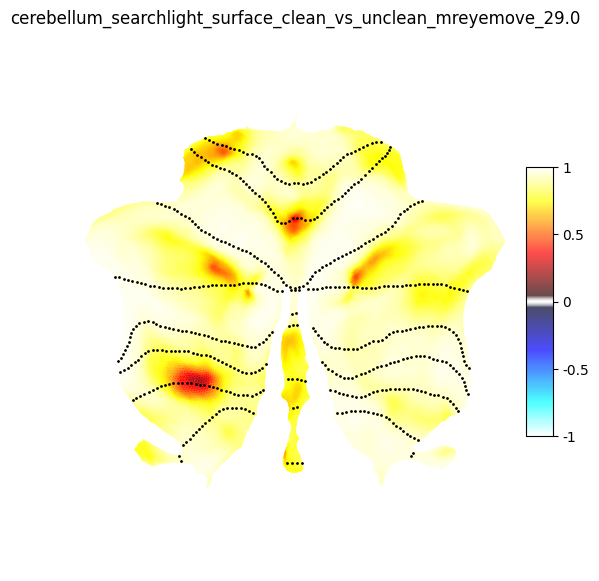

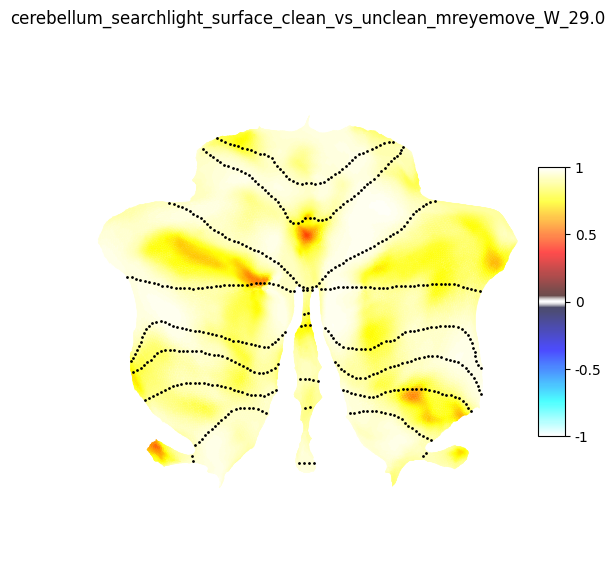

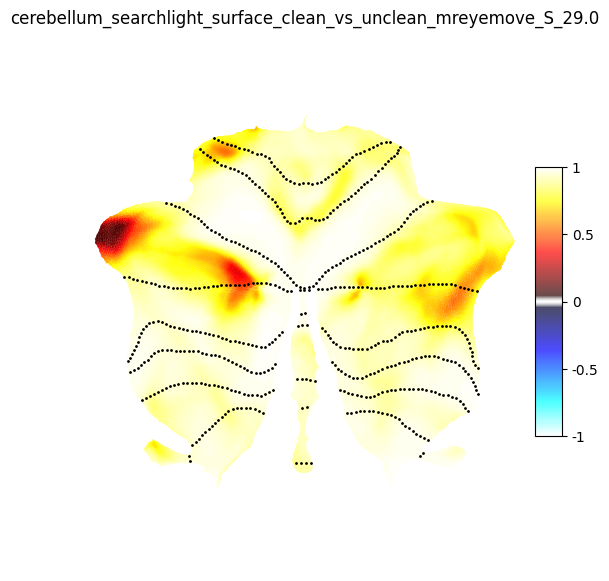

In [57]:
from mreyemove.plotting.glm import custom_cmap

"""
Cerebellum Searchlight
"""

from SUITPy import flatmap
from mreyemove.analysis.searchlight_correlation import surface_searchlight_correlation

config_main_cer = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep_cer.yml")
desc_add_main_cer = construct_desc(dataset=mrio_clean, config=config_main_cer)
desc_add_main_cer = f"{desc_add_main_cer}-{config_main_cer.second_level.method}"
print(desc_add_main_cer)

config_unclean_cer = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep_cer.yml")
desc_add_unclean_cer = construct_desc(dataset=mrio_unclean, config=config_unclean_cer)
desc_add_unclean_cer = f"{desc_add_unclean_cer}-{config_unclean_cer.second_level.method}"
print(desc_add_unclean_cer)

for contrast in comparisons:
    print(f"\n=== {contrast} clean vs unclean ===")
    title = f"cerebellum_searchlight_surface_clean_vs_unclean_{contrast}_{radius_mm}"
    
    vol_a,_ = mrio_clean.load_FLAME_result(contrast=contrast, desc_add=desc_add_main_cer)
    vol_b,_ = mrio_unclean.load_FLAME_result(contrast=contrast, desc_add=desc_add_unclean_cer)
    
    surf_a = flatmap.vol_to_surf(vol_a.t_stat, space='FSL')
    surf_b = flatmap.vol_to_surf(vol_b.t_stat, space='FSL')
    
    results = surface_searchlight_correlation(
        map_a_surf=surf_a,
        map_b_surf=surf_b,
        neighborhoods=cerebellum_neighbourhoods,
        min_vertices=10,
    )
    
    corr_maps[f"cerebellum_clean_vs_unclean_{contrast}"] = results
    
    ax = flatmap.plot(data=results, cmap=custom_cmap(), 
            new_figure=True, 
            colorbar=True, 
            render='matplotlib',
            cscale=[-1.0, 1.0])
    ax.set_title(title)

    output_path = FIG_DIR / f"{title}.png"

    ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")


# Main vs Convolved FD 

In [58]:
config_main = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep.yml")
desc_add_main = construct_desc(dataset=mrio_clean, config=config_main)
desc_add_main = f"{desc_add_main}-{config_main.second_level.method}"
print(desc_add_main)


config_modelled = GLMConfig.from_yaml(CONFIG_DIR / "conv_fd_sleep.yml")
desc_add_modelled = construct_desc(dataset=mrio_unclean, config=config_modelled)
desc_add_modelled = f"{desc_add_modelled}-{config_modelled.second_level.method}"
print(desc_add_modelled)


clean-original-sleep-flame
conv-fd-sleep-flame


In [59]:
"""
Cerebrum Searchlight
"""

from SleepMReye.plotting import plot_surface_searchlight
from mreyemove.analysis.searchlight_correlation import run_fsaverage_surface_searchlight_correlation

for contrast in comparisons:
    print(f"\n=== {contrast} clean vs modelled ===")

    data_a, _ = mrio_clean.load_FLAME_result(contrast=contrast, desc_add=desc_add_main)
    data_b, _ = mrio_unclean.load_FLAME_result(contrast=contrast, desc_add=desc_add_modelled)

    print(data_a.t_stat.shape)

    corr_map, _ = run_fsaverage_surface_searchlight_correlation(
        data_b.t_stat, data_a.t_stat,
        surf_mesh=surf_mesh,
        neighborhoods=cerebrum_neighborhoods
    )
    corr_maps[f"clean_vs_modelled_{contrast}"] = corr_map

    # plot_surface_searchlight(
    #     corr_map,
    #     surf_mesh=surf_mesh,
    #     inflate=True,
    #     title=f"Searchlight r: clean_vs_unclean_{contrast} ({radius_mm}mm geodesic)",
    #     output_file=FIG_DIR / f"clean_vs_unclean_{contrast}_{radius_mm}mm_correlation_map.png"
    # )



=== mreyemove clean vs modelled ===
(53, 65, 43)
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
n valid vertices = 163831
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
Median r: 0.9541832804679871
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
n valid vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
Median r: 0.9577804505825043
Joint hemisphere median r: 0.9560785889625549

=== mreyemove_W clean vs modelled ===
(53, 65, 43)
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
n valid vertices = 163828
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
Median r: 0.9532257914543152
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
n valid vertices = 163842
r_valid >= 

In [60]:
"""
Cerebellum Searchlight
"""


config_main_cer = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep_cer.yml")
desc_add_main_cer = construct_desc(dataset=mrio_clean, config=config_main_cer)
desc_add_main_cer = f"{desc_add_main_cer}-{config_main_cer.second_level.method}"
print(desc_add_main_cer)

config_modelled = GLMConfig.from_yaml(CONFIG_DIR / "conv_fd_sleep_cer.yml")
desc_add_modelled = construct_desc(dataset=mrio_unclean, config=config_modelled)
desc_add_modelled = f"{desc_add_modelled}-{config_modelled.second_level.method}"
print(desc_add_modelled)


clean-original-sleep-incl-nrem3-cer-cov-flame
conv-fd-sleep-cer-cov-flame



=== mreyemove clean vs modelled ===
n vertices = 28935
r_valid >=  0.3: 99.6%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 99.9%
r_valid <= -0.3: 0.0%
Median r: 0.9183194935321808

=== mreyemove_W clean vs modelled ===
n vertices = 28935
r_valid >=  0.3: 99.7%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
Median r: 0.9206932187080383

=== mreyemove_S clean vs modelled ===
n vertices = 28935
r_valid >=  0.3: 99.1%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 99.5%
r_valid <= -0.3: 0.0%
Median r: 0.9316381216049194


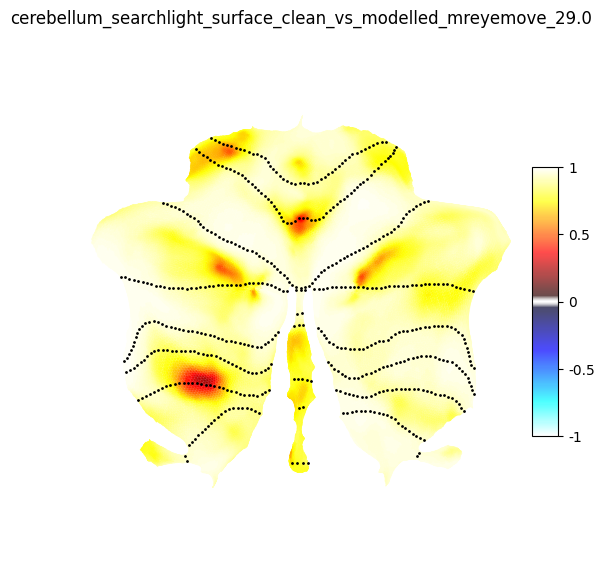

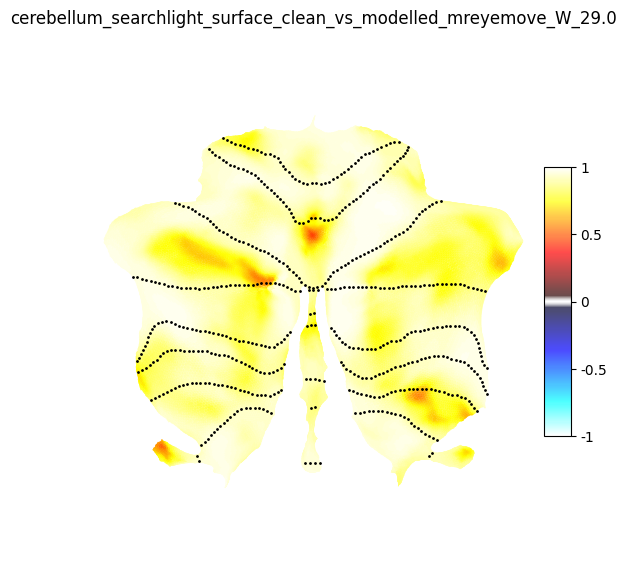

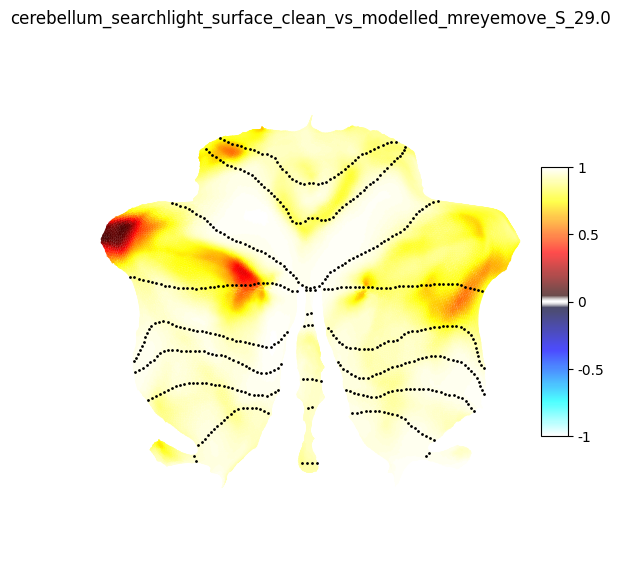

In [61]:



from SUITPy import flatmap
from mreyemove.analysis.searchlight_correlation import surface_searchlight_correlation

for contrast in comparisons:
    print(f"\n=== {contrast} clean vs modelled ===")
    title = f"cerebellum_searchlight_surface_clean_vs_modelled_{contrast}_{radius_mm}"

    vol_a, _ = mrio_clean.load_FLAME_result(contrast=contrast, desc_add=desc_add_main_cer)
    vol_b, _ = mrio_unclean.load_FLAME_result(contrast=contrast, desc_add=desc_add_unclean)

    surf_a = flatmap.vol_to_surf(vol_a.t_stat, space='FSL')
    surf_b = flatmap.vol_to_surf(vol_b.t_stat, space='FSL')

    results = surface_searchlight_correlation(
        map_a_surf=surf_a,
        map_b_surf=surf_b,
        neighborhoods=cerebellum_neighbourhoods,
        min_vertices=10,
    )

    corr_maps[f"cerebellum_clean_vs_modelled_{contrast}"] = results

    ax = flatmap.plot(data=results, cmap=custom_cmap(),
                      new_figure=True,
                      colorbar=True,
                      render='matplotlib',
                      cscale=[-1.0, 1.0])
    ax.set_title(title)

    output_path = FIG_DIR / f"{title}.png"

    ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")
